In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data = pd.read_csv("customer_churn_dataset.csv")

In [3]:
data.isnull().sum()

tenure_months             0
monthly_usage_hours       0
has_multiple_devices      0
customer_support_calls    0
payment_failures          0
is_premium_plan           0
churn                     0
dtype: int64

In [4]:
data

,tenure_months,monthly_usage_hours,has_multiple_devices,customer_support_calls,payment_failures,is_premium_plan,churn
0,39,30.953928,0,1,0,0,0
1,52,20.485203,0,0,0,0,0
2,29,21.684462,0,1,1,0,0
3,15,27.894281,0,1,0,1,0
4,43,19.250190,1,1,0,0,0
...,...,...,...,...,...,...,...
49995,20,23.566169,0,1,0,1,0
49996,18,20.270705,0,1,0,1,0
49997,18,20.667153,0,1,0,0,0
49998,42,19.222202,1,1,0,0,0


In [5]:
X = data.iloc[: ,: -1]

In [6]:
X

,tenure_months,monthly_usage_hours,has_multiple_devices,customer_support_calls,payment_failures,is_premium_plan
0,39,30.953928,0,1,0,0
1,52,20.485203,0,0,0,0
2,29,21.684462,0,1,1,0
3,15,27.894281,0,1,0,1
4,43,19.250190,1,1,0,0
...,...,...,...,...,...,...
49995,20,23.566169,0,1,0,1
49996,18,20.270705,0,1,0,1
49997,18,20.667153,0,1,0,0
49998,42,19.222202,1,1,0,0


In [7]:
y=data.iloc[:,-1]

In [8]:
y

0        0
1        0
2        0
3        0
4        0
        ..
49995    0
49996    0
49997    0
49998    0
49999    0
Name: churn, Length: 50000, dtype: int64

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30,random_state=0)

In [11]:
from sklearn.preprocessing  import StandardScaler

In [12]:
sc=StandardScaler()

In [13]:
X_train = sc.fit_transform(X_train)

In [14]:
X_train

array([[-1.58465162, -1.98533416, -0.81338966, -1.09600525, -0.33253911,
         1.528565  ],
       [-1.64353033, -0.11035893, -0.81338966,  0.72343572, -0.33253911,
        -0.65420836],
       [-0.52483476, -0.52529099,  1.22942306, -0.18628476, -0.33253911,
         1.528565  ],
       ...,
       [-1.58465162, -0.56546856, -0.81338966,  0.72343572, -0.33253911,
        -0.65420836],
       [ 0.88825437,  1.3639442 , -0.81338966, -1.09600525, -0.33253911,
         1.528565  ],
       [ 1.12376923, -1.20794773,  1.22942306,  0.72343572, -0.33253911,
        -0.65420836]], shape=(35000, 6))

In [15]:
X_test = sc.transform(X_test)

In [16]:
X_test

array([[ 0.12283109,  1.13477078,  1.22942306,  0.72343572, -0.33253911,
        -0.65420836],
       [-1.05474319, -0.18113399,  1.22942306, -1.09600525, -0.33253911,
        -0.65420836],
       [-1.34913676, -0.17798832, -0.81338966,  2.5428767 , -0.33253911,
        -0.65420836],
       ...,
       [-1.58465162, -0.65387252,  1.22942306, -1.09600525, -0.33253911,
        -0.65420836],
       [-1.29025805,  1.41324574, -0.81338966,  0.72343572, -0.33253911,
        -0.65420836],
       [ 1.12376923,  1.52219181,  1.22942306,  0.72343572,  3.00716504,
        -0.65420836]], shape=(15000, 6))

In [17]:
from sklearn.linear_model import LogisticRegression

In [18]:
classifier = LogisticRegression()

In [19]:
from sklearn.model_selection import GridSearchCV
parameter = {'penalty':['l1', 'l2', 'elasticnet'],'C':[1,2,3,4,5,6,10,20,30,40,50],'max_iter':[100,200,300]}

In [20]:
classifier_regression=GridSearchCV(classifier,param_grid=parameter,scoring='accuracy',cv=5)

In [21]:
classifier_regression.fit(X_train,y_train)

C:\Users\f15ga\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\f15ga\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\f15ga

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [1, 2, ...], 'max_iter': [100, 200, ...], 'penalty': ['l1', 'l2', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also

In [22]:
print(classifier_regression.best_params_)

{'C': 1, 'max_iter': 100, 'penalty': 'l2'}


In [23]:
print(classifier_regression.best_score_)

0.9806857142857144


In [24]:
y_pred =classifier_regression.predict(X_test)

In [25]:
# acccuracy score
from sklearn.metrics import accuracy_score,classification_report

In [26]:
score = accuracy_score(y_pred,y_test)

In [27]:
data.columns

Index(['tenure_months', 'monthly_usage_hours', 'has_multiple_devices',
       'customer_support_calls', 'payment_failures', 'is_premium_plan',
       'churn'],
      dtype='str')

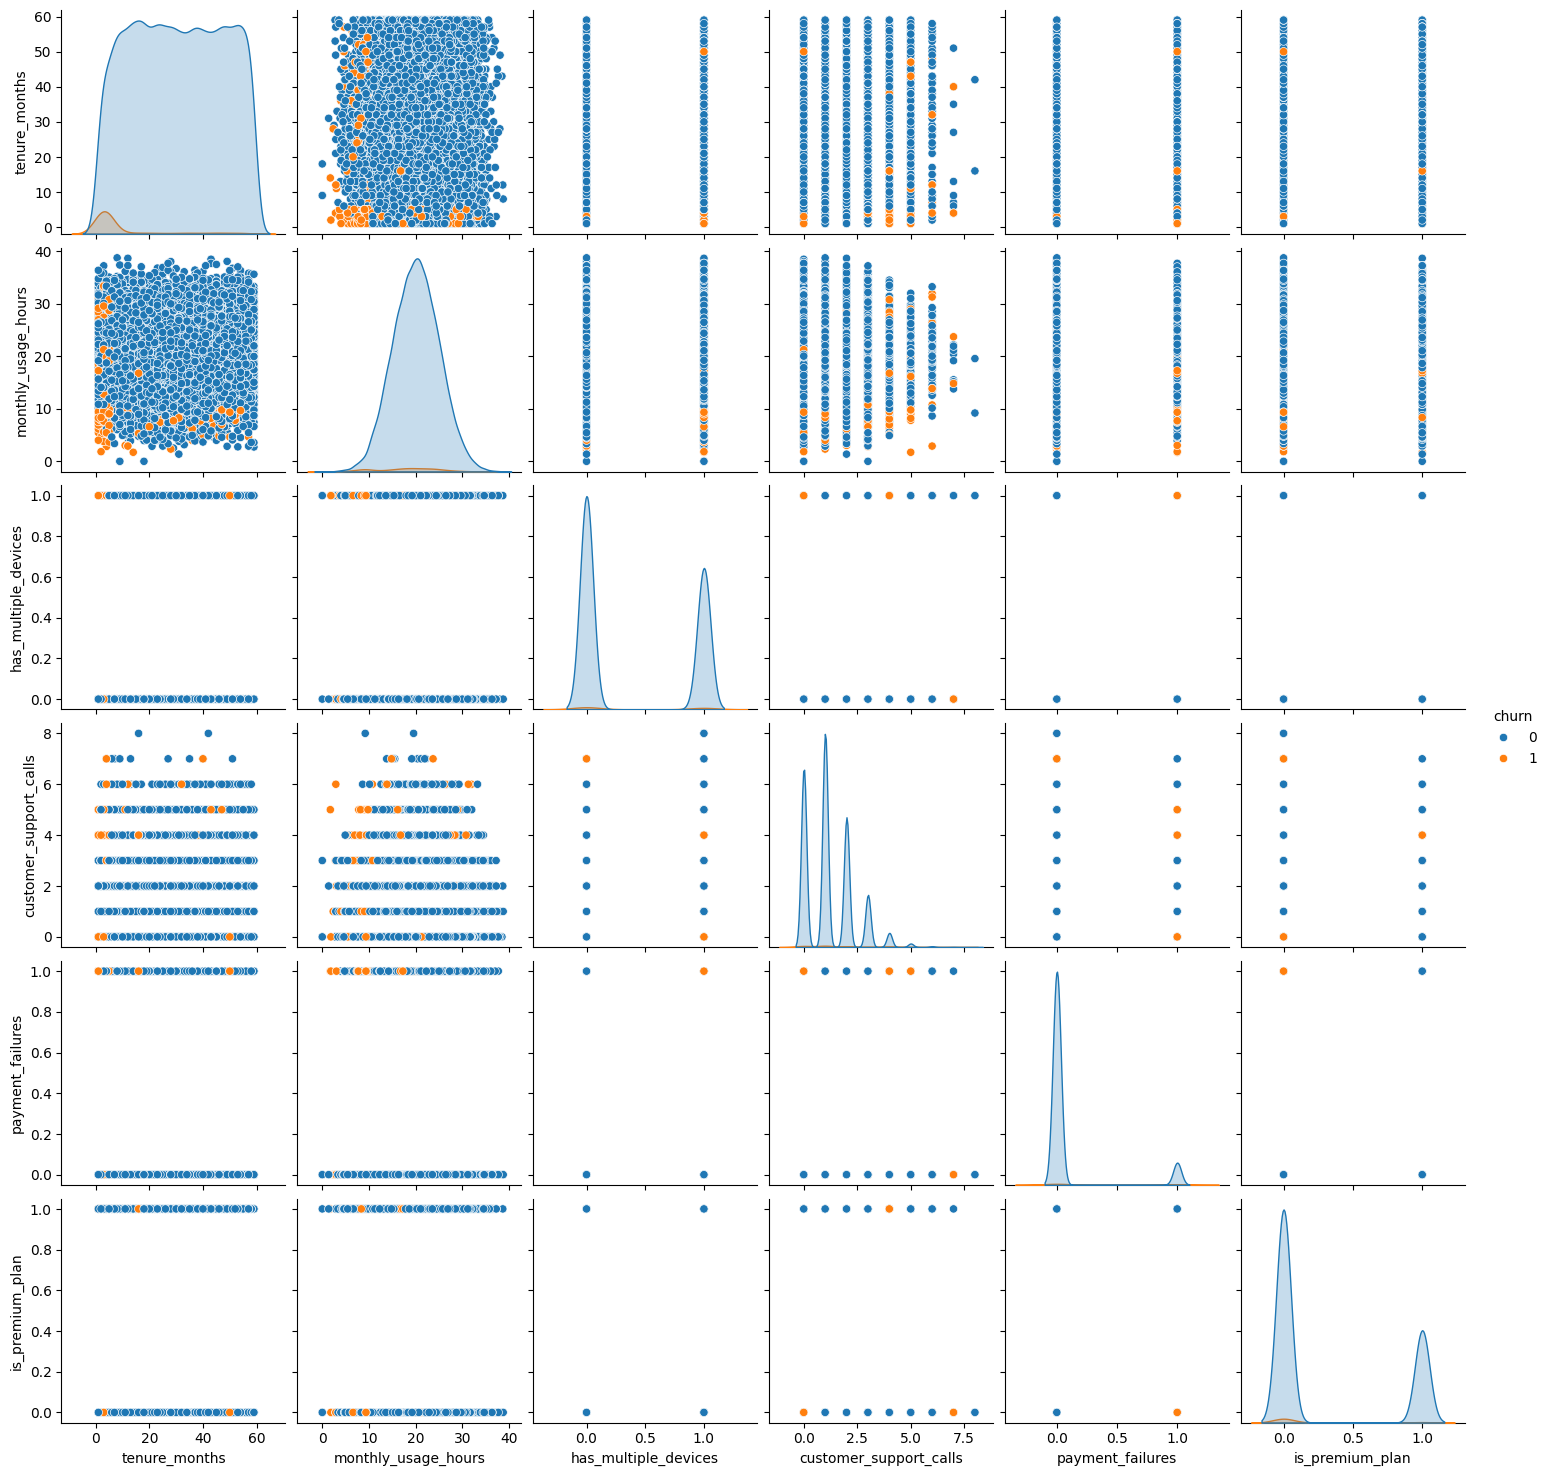

In [28]:
sns.pairplot(data,hue='churn')